In [1]:
!pip install opencv-python

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pathlib
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
import pathlib

In [3]:
import pathlib
from tensorflow import keras

dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

data_dir = keras.utils.get_file("flower_photos", origin=dataset_url, untar=True)

data_dir = pathlib.Path(data_dir)

print("data_dir =", data_dir)

# Task 03: Data Exploration
if (data_dir / "flower_photos").exists():
    data_dir = data_dir / "flower_photos"
    print("Fixed data_dir =", data_dir)

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
data_dir = /root/.keras/datasets/flower_photos
Fixed data_dir = /root/.keras/datasets/flower_photos/flower_photos


In [4]:
import pathlib
from tensorflow import keras

dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

data_dir = keras.utils.get_file("flower_photos", origin=dataset_url, untar=True)
data_dir = pathlib.Path(data_dir)

# Fix path if nested
if (data_dir / "flower_photos").exists():
    data_dir = data_dir / "flower_photos"
    print("Fixed data_dir =", data_dir)

# Count images
print("Total jpg:", len(list(data_dir.glob("*/*.jpg"))))

print("Class counts:")
for cls in ["roses","daisy","dandelion","sunflowers","tulips"]:
    print(cls, len(list(data_dir.glob(f"{cls}/*.jpg"))))

Fixed data_dir = /root/.keras/datasets/flower_photos/flower_photos
Total jpg: 3670
Class counts:
roses 641
daisy 633
dandelion 898
sunflowers 699
tulips 799


In [5]:
flowers_images_dict = {
    'roses': list(data_dir.glob('roses/*')),
    'daisy': list(data_dir.glob('daisy/*')),
    'dandelion': list(data_dir.glob('dandelion/*')),
    'sunflowers': list(data_dir.glob('sunflowers/*')),
    'tulips': list(data_dir.glob('tulips/*')),
}

flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

In [6]:
IMG_SIZE = (224, 224)      # Fill
BATCH_SIZE = 32            # Fill
SEED = 123

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split = 0.25,
    subset = "training",
    seed = SEED,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split = 0.25,
    subset = "validation",
    seed = SEED,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)

Found 3670 files belonging to 5 classes.
Using 2753 files for training.
Found 3670 files belonging to 5 classes.
Using 917 files for validation.
Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


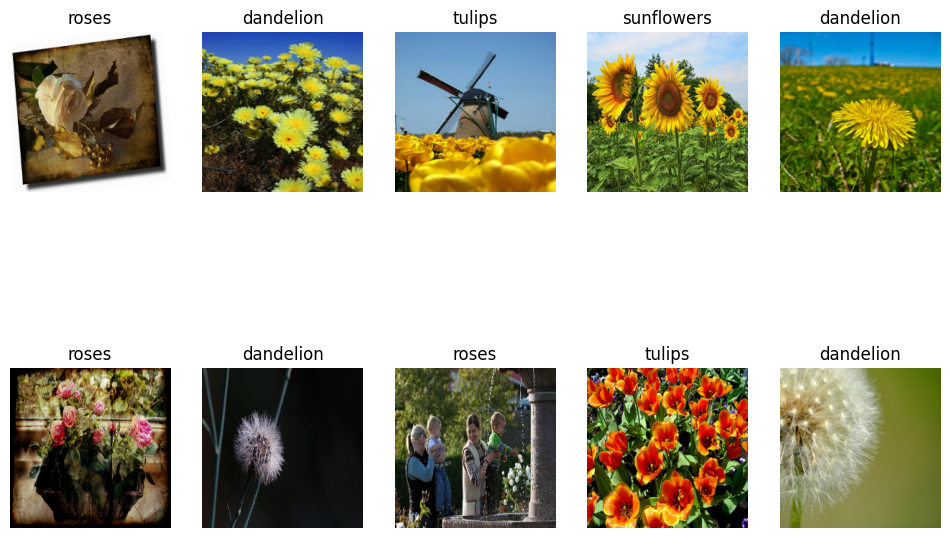

In [7]:
images, labels = next(iter(train_ds))

plt.figure(figsize=(12, 8))
for i in range(10):
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[int(labels[i])])
    plt.axis("off")
plt.show()

In [8]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

normalizer = layers.Rescaling(1./255)

In [9]:
baseline_model = keras.Sequential([

    layers.Input(shape = IMG_SIZE + (3,)),

    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation="softmax")
])

baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,405 (431.27 KB)

 Trainable params: 110,405 (431.27 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history_baseline = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 22s 120ms/step - accuracy: 0.3160 - loss: 1.4841 - val_accuracy: 0.4100 - val_loss: 1.2934
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.4337 - loss: 1.2626 - val_accuracy: 0.4667 - val_loss: 1.2261
Epoch 3/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.4864 - loss: 1.1856 - val_accuracy: 0.5224 - val_loss: 1.1464
Epoch 4/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.5314 - loss: 1.1313 - val_accuracy: 0.5562 - val_loss: 1.1058
Epoch 5/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.5474 - loss: 1.1128 - val_accuracy: 0.5551 - val_loss: 1.0922
Epoch 6/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.5746 - loss: 1.0602 - val_accuracy: 0.5638 - val_loss: 1.0609
Epoch 7/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.5961 - loss: 1.0382 - val_accuracy: 0.5671 - val_loss: 1.0530
Epoch 8/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.5903 - loss: 1.0224 - val_accuracy: 0.5812 -

In [11]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape = IMG_SIZE + (3,),
    include_top = False,    # Fill
    weights = "imagenet"        # Fill
)

base_model.trainable = False  # Freeze or not?

tl_model = models.Sequential([
    layers.Input(shape = IMG_SIZE + (3,)),
    layers.Rescaling(1./255),
    base_model,
    layers.GlobalAveragePooling2D(),   # Fill
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation="softmax")
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
tl_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

tl_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [13]:
history_tl = tl_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 47s 345ms/step - accuracy: 0.6873 - loss: 0.8199 - val_accuracy: 0.8266 - val_loss: 0.4965
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.8405 - loss: 0.4556 - val_accuracy: 0.8604 - val_loss: 0.4044
Epoch 3/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.8740 - loss: 0.3730 - val_accuracy: 0.8691 - val_loss: 0.3829
Epoch 4/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.8881 - loss: 0.3251 - val_accuracy: 0.8757 - val_loss: 0.3594
Epoch 5/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.8961 - loss: 0.2977 - val_accuracy: 0.8909 - val_loss: 0.3465
Epoch 6/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9168 - loss: 0.2597 - val_accuracy: 0.8909 - val_loss: 0.3343
Epoch 7/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9263 - loss: 0.2432 - val_accuracy: 0.8942 - val_loss: 0.3286
Epoch 8/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9292 - loss: 0.2232 - val_accuracy: 0.8986 -

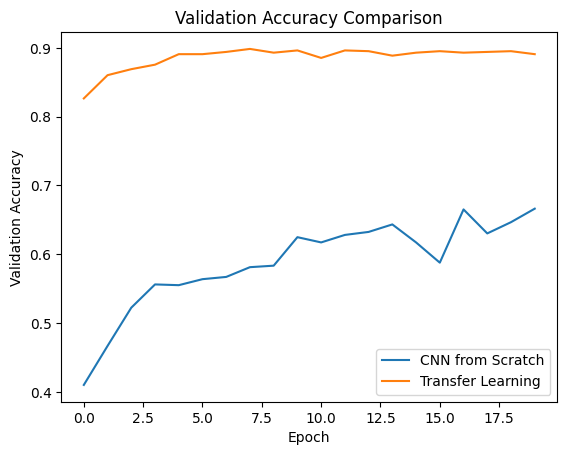

In [14]:
plt.figure()

plt.plot(history_baseline.history["val_accuracy"],
         label="CNN from Scratch")

plt.plot(history_tl.history["val_accuracy"],
         label="Transfer Learning")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()

plt.show()

In [15]:
import pandas as pd

summary = pd.DataFrame([
    {
        "Model": "CNN from Scratch",
        "Epochs": len(history_baseline.history["val_accuracy"]),
        "Total Params": baseline_model.count_params(),
        "Best Val Acc": max(history_baseline.history["val_accuracy"])
    },
    {
        "Model": "Transfer Learning",
        "Epochs": len(history_tl.history["val_accuracy"]),
        "Total Params": tl_model.count_params(),
        "Best Val Acc": max(history_tl.history["val_accuracy"])
    }
])

summary

,Model,Epochs,Total Params,Best Val Acc
0,CNN from Scratch,20,110405,0.666303
1,Transfer Learning,20,2264389,0.898582


In [16]:
import numpy as np

def get_true_and_pred(model, dataset):
    y_true = []
    y_pred = []

    for x_batch, y_batch in dataset:
        probs = model.predict(x_batch, verbose=0)     # (batch, num_classes)
        preds = np.argmax(probs, axis=1)             # predicted class index

        y_true.extend(y_batch.numpy())
        y_pred.extend(preds)

    return np.array(y_true), np.array(y_pred)

y_true_base, y_pred_base = get_true_and_pred(baseline_model, val_ds)
y_true_tl,   y_pred_tl   = get_true_and_pred(tl_model, val_ds)

In [17]:
acc_base = (y_true_base == y_pred_base).mean()
acc_tl   = (y_true_tl == y_pred_tl).mean()

print("Baseline CNN Test Accuracy:", round(acc_base, 4))
print("Transfer Learning Test Accuracy:", round(acc_tl, 4))

Baseline CNN Test Accuracy: 0.6663
Transfer Learning Test Accuracy: 0.8909


<Figure size 640x480 with 0 Axes>

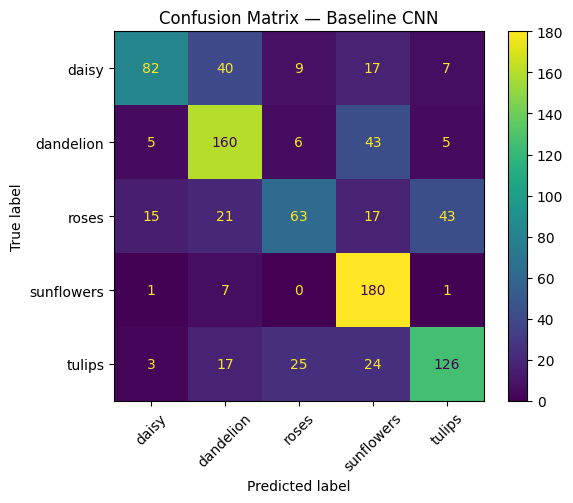

<Figure size 640x480 with 0 Axes>

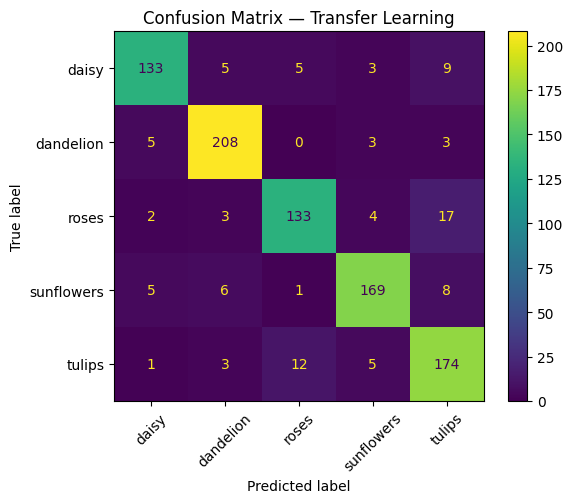

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_base = confusion_matrix(y_true_base, y_pred_base)
cm_tl   = confusion_matrix(y_true_tl, y_pred_tl)

plt.figure()
ConfusionMatrixDisplay(cm_base, display_labels=class_names).plot(xticks_rotation=45)
plt.title("Confusion Matrix — Baseline CNN")
plt.show()

plt.figure()
ConfusionMatrixDisplay(cm_tl, display_labels=class_names).plot(xticks_rotation=45)
plt.title("Confusion Matrix — Transfer Learning")
plt.show()

In [19]:
from sklearn.metrics import classification_report

print("=== Baseline CNN Report ===")
print(classification_report(y_true_base, y_pred_base, target_names=class_names))

print("=== Transfer Learning Report ===")
print(classification_report(y_true_tl, y_pred_tl, target_names=class_names))

=== Baseline CNN Report ===
              precision    recall  f1-score   support

       daisy       0.77      0.53      0.63       155
   dandelion       0.65      0.73      0.69       219
       roses       0.61      0.40      0.48       159
  sunflowers       0.64      0.95      0.77       189
      tulips       0.69      0.65      0.67       195

    accuracy                           0.67       917
   macro avg       0.67      0.65      0.65       917
weighted avg       0.67      0.67      0.65       917

=== Transfer Learning Report ===
              precision    recall  f1-score   support

       daisy       0.91      0.86      0.88       155
   dandelion       0.92      0.95      0.94       219
       roses       0.88      0.84      0.86       159
  sunflowers       0.92      0.89      0.91       189
      tulips       0.82      0.89      0.86       195

    accuracy                           0.89       917
   macro avg       0.89      0.89      0.89       917
weighted avg    

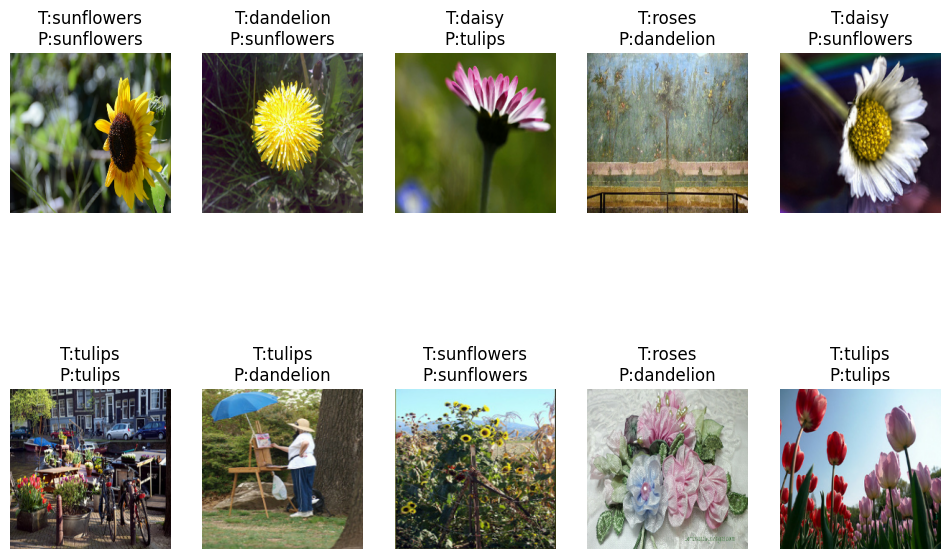

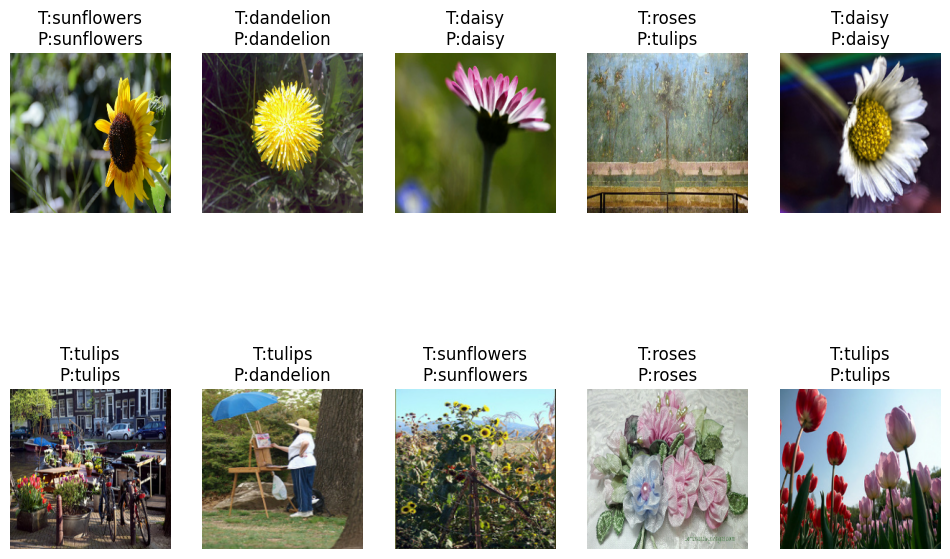

In [20]:
import matplotlib.pyplot as plt

def show_prediction_grid(model, dataset, class_names, n=10):
    images, labels = next(iter(dataset))
    probs = model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)

    plt.figure(figsize=(12,8))
    for i in range(n):
        ax = plt.subplot(2, 5, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        t = class_names[int(labels[i])]
        p = class_names[int(preds[i])]
        plt.title(f"T:{t}\nP:{p}")
        plt.axis("off")
    plt.show()

show_prediction_grid(baseline_model, val_ds, class_names, n=10)
show_prediction_grid(tl_model, val_ds, class_names, n=10)

In [21]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

IMG_SIZE = (224, 224)

def preprocess_image(image_path):
    img = load_img(image_path, target_size=IMG_SIZE)
    img_array = img_to_array(img)

    img_array = img_array / 255.0   # normalize
    img_array = np.expand_dims(img_array, axis=0)

    return img_array

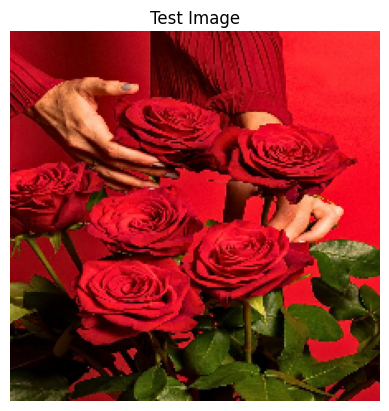

In [24]:
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img

IMG_SIZE = (224,224)

img = load_img("img03.jpg", target_size=IMG_SIZE)

plt.imshow(img)
plt.axis("off")
plt.title("Test Image")
plt.show()

In [26]:
test_image = preprocess_image("img03.jpg")

predictions = tl_model.predict(test_image)

predicted_class = np.argmax(predictions[0])
confidence = np.max(predictions[0])

print("Predicted Flower:", class_names[predicted_class])
print("Confidence:", round(confidence*100, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Predicted Flower: dandelion
Confidence: 76.19 %


In [27]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape = IMG_SIZE + (3,),
    include_top = False,
    weights = "imagenet"
)

base_model.trainable = True

fine_tune_at = 100

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

fine_tune = models.Sequential([
    layers.Input(shape = IMG_SIZE + (3,)),
    layers.Rescaling(1./255),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(5, activation="softmax")
])

fine_tune.compile(
    optimizer = optimizers.Adam(learning_rate=1e-5),
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

In [28]:
history_ft=fine_tune.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 51s 268ms/step - accuracy: 0.4076 - loss: 1.4470 - val_accuracy: 0.4057 - val_loss: 1.3689
Epoch 2/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.7036 - loss: 0.8243 - val_accuracy: 0.5780 - val_loss: 1.0617
Epoch 3/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.8104 - loss: 0.5843 - val_accuracy: 0.6674 - val_loss: 0.8524
Epoch 4/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.8689 - loss: 0.4508 - val_accuracy: 0.7426 - val_loss: 0.7074
Epoch 5/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.8979 - loss: 0.3628 - val_accuracy: 0.7841 - val_loss: 0.6001
Epoch 6/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.9197 - loss: 0.3018 - val_accuracy: 0.8113 - val_loss: 0.5255
Epoch 7/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.9426 - loss: 0.2489 - val_accuracy: 0.8342 - val_loss: 0.4766
Epoch 8/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.9586 - loss: 0.2073 - val_accuracy: 0.8451 -

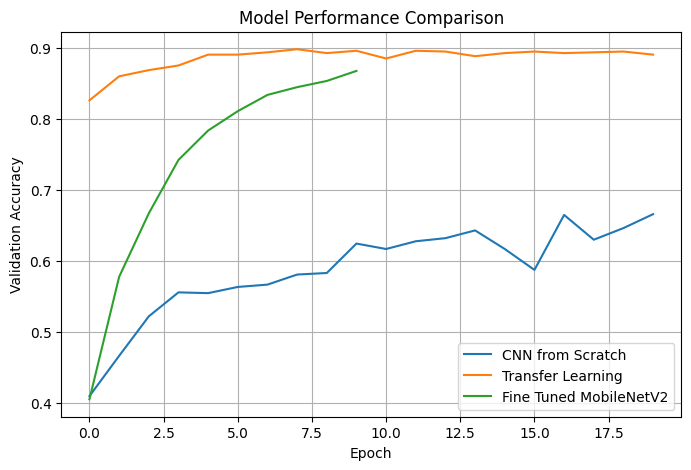

In [29]:
plt.figure(figsize=(8,5))

plt.plot(history_baseline.history["val_accuracy"],
         label="CNN from Scratch")

plt.plot(history_tl.history["val_accuracy"],
         label="Transfer Learning")

plt.plot(history_ft.history["val_accuracy"],
         label="Fine Tuned MobileNetV2")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Model Performance Comparison")
plt.legend()
plt.grid(True)

plt.show()

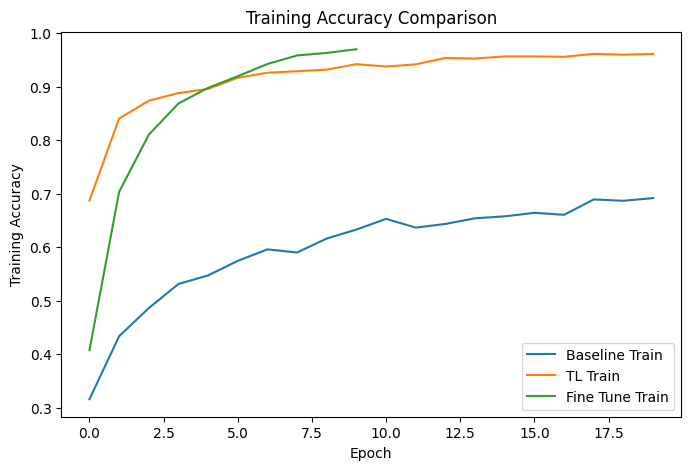

In [30]:
plt.figure(figsize=(8,5))

plt.plot(history_baseline.history["accuracy"], label="Baseline Train")
plt.plot(history_tl.history["accuracy"], label="TL Train")
plt.plot(history_ft.history["accuracy"], label="Fine Tune Train")

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy Comparison")
plt.legend()
plt.show()